In [3]:
!pip install datasets faiss-cpu sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 95.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import pickle
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

In [5]:
dataset = load_dataset("rifkiaputri/idk-mrc")

print(dataset)
print("\nSample:")
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.55k [00:00<?, ?B/s]

train.json:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

valid.json:   0%|          | 0.00/350k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/382k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3659 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/358 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/378 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['qas', 'context'],
        num_rows: 3659
    })
    validation: Dataset({
        features: ['qas', 'context'],
        num_rows: 358
    })
    test: Dataset({
        features: ['qas', 'context'],
        num_rows: 378
    })
})

Sample:
{'qas': [{'answers': [{'answer_start': 26, 'text': 'Pasuruan, Jawa Timur'}], 'id': 'indonesian-1653118927826418646-2', 'is_impossible': False, 'question': 'dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?'}, {'answers': [], 'id': 'indonesian-2988585593205955820-unans-h-2', 'is_impossible': True, 'question': 'di manakah  Dr. Ernest François Eugène Douwes Dekker meninggal?'}], 'context': 'Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, Auguste Henri Edoeard Douwes Dekker, adalah seorang agen di bank kelas kakap Nederlandsch Indisch Escompto

In [6]:
sample = dataset['train'][0]
print("Fields:", list(sample.keys()))

print("\nContext:", sample['context'][:200])

print("\nJumlah QA pairs:", len(sample['qas']))
print("\nSample:")
print("  Question  :", sample['qas'][0]['question'])
print("  Answers   :", sample['qas'][0]['answers'])
print("  Impossible:", sample['qas'][0]['is_impossible'])

Fields: ['qas', 'context']

Context: Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di Universitas Zurich, September 1913. Ayahnya, August

Jumlah QA pairs: 2

Sample:
  Question  : dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?
  Answers   : [{'answer_start': 26, 'text': 'Pasuruan, Jawa Timur'}]
  Impossible: False


In [7]:
raw_contexts = dataset['train']['context']

unique_contexts = list(set(raw_contexts))
print(f"Total raw context : {len(raw_contexts)}")
print(f"Total unique context  : {len(unique_contexts)}")

corpus = {i: text for i, text in enumerate(unique_contexts)}
doc_ids   = list(corpus.keys())
doc_texts = list(corpus.values())

print(f"\nSample corpus[0]: {corpus[0][:150]}...")

Total raw context : 3659
Total unique context  : 3659

Sample corpus[0]: Catholic Encyclopedia mengatakan Marcion mungkin juga menjadi salah satu kandidatnya pada saat yang sama. Tertulianus— yang mengembangkan kecenderunga...


In [8]:
qa_pairs = []

for item in dataset['train']:
    context = item['context']
    for qa in item['qas']:
        if not qa['is_impossible'] and len(qa['answers']) > 0:
            qa_pairs.append({
                'question' : qa['question'],
                'answer'   : qa['answers'][0]['text'],
                'context'  : context,
            })

print(f"Total QA pairs yang bisa dijawab: {len(qa_pairs)}")
print(f"\nSample:")
print(f"  Q: {qa_pairs[0]['question']}")
print(f"  A: {qa_pairs[0]['answer']}")

Total QA pairs yang bisa dijawab: 5042

Sample:
  Q: dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?
  A: Pasuruan, Jawa Timur


In [9]:
model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedding_model = SentenceTransformer(model_name)

print(f"Model loaded: {model_name}")

test_vec = embedding_model.encode("Apa ibu kota Indonesia?")
print(f"Shape vector: {test_vec.shape}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: paraphrase-multilingual-MiniLM-L12-v2
Shape vector: (384,)


In [10]:
doc_embeddings = embedding_model.encode(
    doc_texts,
    batch_size=64,
    show_progress_bar=True
)

doc_embeddings = np.array(doc_embeddings).astype('float32')

print(f"\nShape embeddings: {doc_embeddings.shape}")

Batches:   0%|          | 0/58 [00:00<?, ?it/s]


Shape embeddings: (3659, 384)


In [11]:
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

print(f"Total vektor dalam index: {index.ntotal}")

Total vektor dalam index: 3659


In [12]:
with open("corpus.pkl", "wb") as f:
    pickle.dump(corpus, f)

with open("qa_pairs.pkl", "wb") as f:
    pickle.dump(qa_pairs, f)

faiss.write_index(index, "faiss_index.bin")

In [13]:
def retrieve(query: str, k: int) -> list:
    query_vector = embedding_model.encode([query])
    query_vector = np.array(query_vector).astype('float32')

    distances, indices = index.search(query_vector, k)

    results = []
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        results.append({
            'doc_id' : doc_ids[idx],
            'text'   : corpus[doc_ids[idx]],
            'score'  : float(dist),
            'rank'   : rank + 1
        })

    return results

In [14]:
sample_question = qa_pairs[0]['question']
print(f"Query: {sample_question}\n")

for k in [1, 3, 5, 10]:
    results = retrieve(sample_question, k=k)
    print(f"--- K = {k} ---")
    for res in results:
        print(f"  Rank {res['rank']} | Doc ID: {res['doc_id']} | Score: {res['score']:.4f}")
        print(f"  Preview: {res['text'][:100]}...")
    print()

Query: dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?

--- K = 1 ---
  Rank 1 | Doc ID: 2770 | Score: 8.0431
  Preview: Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tu...

--- K = 3 ---
  Rank 1 | Doc ID: 2770 | Score: 8.0431
  Preview: Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tu...
  Rank 2 | Doc ID: 850 | Score: 12.9220
  Preview: Desiderius Erasmus dilaporkan lahir di Rotterdam pada tanggal 28 Oktober, di akhir tahun 1460-an.[1]...
  Rank 3 | Doc ID: 270 | Score: 14.6997
  Preview: Émilie Du Châtelet lahir di Paris, Perancis, pada17 December 1706 dari pasangan Baron Louis Nicholas...

--- K = 5 ---
  Rank 1 | Doc ID: 2770 | Score: 8.0431
  Preview: Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tu...
  Rank 2 | Doc ID: 850 | Score: 12.9220
  Preview: Desiderius Erasmus dilaporkan lahir di Rotterdam pada tang

In [15]:
def get_context_for_generation(query: str, k: int) -> dict:
    retrieved_docs = retrieve(query, k=k)

    return {
        'query'    : query,
        'k'        : k,
        'documents': [
            {
                'doc_id' : doc['doc_id'],
                'text'   : doc['text'],
                'rank'   : doc['rank']
            }
            for doc in retrieved_docs
        ]
    }

# Test
output = get_context_for_generation(qa_pairs[0]['question'], k=3)

print(f"Query : {output['query']}")
print(f"K     : {output['k']}")
print(f"Jumlah dokumen retrieved: {len(output['documents'])}")
for doc in output['documents']:
    print(f"\n  [Doc {doc['rank']}] ID: {doc['doc_id']}")
    print(f"  Preview: {doc['text'][:150]}...")

Query : dimanakah  Dr. Ernest François Eugène Douwes Dekker dilahirkan?
K     : 3
Jumlah dokumen retrieved: 3

  [Doc 1] ID: 2770
  Preview: Douwes Dekker terlahir di Pasuruan, Jawa Timur, pada tanggal 8 Oktober 1879, sebagaimana yang dia tulis pada riwayat hidup singkat saat mendaftar di U...

  [Doc 2] ID: 850
  Preview: Desiderius Erasmus dilaporkan lahir di Rotterdam pada tanggal 28 Oktober, di akhir tahun 1460-an.[1][7] Ia dinamai seturut nama Santo Erasmus dari For...

  [Doc 3] ID: 270
  Preview: Émilie Du Châtelet lahir di Paris, Perancis, pada17 December 1706 dari pasangan Baron Louis Nicholas le Tonnelier de Breteuil dan Gabrielle Anne de Fr...


In [16]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00


In [17]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

In [18]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Qwen loaded successfully!")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen loaded successfully!


In [19]:
def generate_answer(question, k):

    retrieved = get_context_for_generation(question, k)

    context = ""

    for doc in retrieved["documents"]:
        context += f"[Dokumen {doc['rank']}]\n{doc['text']}\n\n"

    messages = [
        {
            "role": "system",
            "content": "Anda adalah sistem Question Answering yang hanya boleh menjawab berdasarkan dokumen yang diberikan."
        },
        {
            "role": "user",
            "content": f"""
Dokumen:
{context}

Pertanyaan:
{question}

Jawab dengan format:

Jawaban: <jawaban singkat>

Sumber: Dokumen <nomor>

Jangan berikan penjelasan tambahan.
"""
        }
    ]

    # Buat chat template Qwen
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False
    )

    # Ambil HANYA token hasil generate
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    response = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return response.strip()

In [20]:
import re

def clean_prediction(text):

    if not isinstance(text, str):
        return ""

    # hapus Sumber: Dokumen 1
    # hapus Sumber: Dokumen [1]
    text = re.sub(
        r"Sumber\s*:\s*Dokumen\s*\[?\d+\]?",
        "",
        text,
        flags=re.IGNORECASE
    )

    # hapus Jawaban:
    text = re.sub(
        r"Jawaban\s*:\s*",
        "",
        text,
        flags=re.IGNORECASE
    )

    return text.strip()

In [21]:
import pandas as pd
import random

random.seed(42)

sample_size = 100

sampled_qa = random.sample(
    qa_pairs,
    sample_size
)

results = []

for k in [1, 3, 5, 10]:

    print(f"\n=== K = {k} ===")

    for item in sampled_qa:

        raw_prediction = generate_answer(
            item["question"],
            k=k
        )

        prediction = clean_prediction(
            raw_prediction
        )

        results.append({
            "k": k,
            "question": item["question"],
            "ground_truth": item["answer"],
            "prediction": prediction
        })

df_results = pd.DataFrame(results)

print(df_results.shape)

df_results.head()


=== K = 1 ===


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



=== K = 3 ===

=== K = 5 ===

=== K = 10 ===
(400, 4)


,k,question,ground_truth,prediction
0,1,berapakah jumlah sekuel Harry Potter?,tujuh,Jumlah sekuel Harry Potter adalah 8.
1,1,Kapan formula one pertama kali diselenggarakan ?,1950,Formula One pertama kali diselenggarakan pada ...
2,1,dari manakah Makhluk mitologis bernama genderu...,Pulau Jawa,dari mitologi Jawa
3,1,apakah arti kata Romusha?,buruh,Arti kata Romusha: Pekerja atau pekerjaan di I...
4,1,Kapan Aria Wiraraja lahir?,1232 Masehi,Aria Wiraraja lahir pada tahun 1257.


In [22]:
pd.set_option("display.max_colwidth", None)

df_results[
    ["question", "ground_truth", "prediction"]
].head(20)

,question,ground_truth,prediction
0,berapakah jumlah sekuel Harry Potter?,tujuh,Jumlah sekuel Harry Potter adalah 8.
1,Kapan formula one pertama kali diselenggarakan ?,1950,Formula One pertama kali diselenggarakan pada tahun 1950.
2,dari manakah Makhluk mitologis bernama genderuwo berasal?,Pulau Jawa,dari mitologi Jawa
3,apakah arti kata Romusha?,buruh,Arti kata Romusha: Pekerja atau pekerjaan di Indonesia yang dipekerjakan secara paksa oleh Jepang selama penjajahan mereka di Indonesia.
4,Kapan Aria Wiraraja lahir?,1232 Masehi,Aria Wiraraja lahir pada tahun 1257.
5,Siapakah nama pemimpin dalam gereja ?,Paus,Nama pemimpin dalam gereja adalah Yang Mulia Bapa Adolfo Nicolás.
6,Berapakah jarak Neptunus dengan Matahari?,101jutakm,Jarak antara Neptunus dan Matahari mencapai 101juta km.
7,umur berapakah Albert einstein meninggal?,76,Umur Einstein saat meninggal: 76 tahun.
8,Siapakah penegak hukum di Indonesia?,Kepolisian Negara Republik Indonesia,Letkol. Ventje Sumual
9,Apakah tujuan utama dibentuknya Mujahidin KOMPAK?,"membantu korban konflik dan bencana, kelompok ini telah dikaitkan dengan penyediaan dana untuk organisasi teroris seperti Jemaah Islamiyah serta melakukan serangan terhadap kelompok Kristen setempat",Tidak ada jawaban yang sesuai untuk pertanyaan tersebut karena informasi tentang tujuan pembentukan Mujahidin KOMPAK tidak ditemukan dalam dokumen yang diberikan.


In [23]:
!pip install rouge-score bert-score nltk -q

In [24]:
import re
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bertscore
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Semua library evaluasi berhasil di-import.")

Semua library evaluasi berhasil di-import.


In [25]:
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
smoother = SmoothingFunction().method1

def compute_rouge(prediction: str, reference: str) -> dict:
    if not prediction or not reference:
        return {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
    scores = rouge.score(reference, prediction)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure,
    }

def compute_bleu(prediction: str, reference: str) -> float:
    if not prediction or not reference:
        return 0.0
    ref_tokens  = reference.split()
    pred_tokens = prediction.split()
    return sentence_bleu(
        [ref_tokens],
        pred_tokens,
        weights=(1, 0, 0, 0),        # BLEU-1
        smoothing_function=smoother
    )

print("Fungsi compute_rouge & compute_bleu siap.")

Fungsi compute_rouge & compute_bleu siap.


In [26]:
rouge_bleu_rows = []

for _, row in df_results.iterrows():
    pred = str(row['prediction'])
    ref  = str(row['ground_truth'])
    r    = compute_rouge(pred, ref)
    b    = compute_bleu(pred, ref)
    rouge_bleu_rows.append({
        'k'      : row['k'],
        'rouge1' : r['rouge1'],
        'rouge2' : r['rouge2'],
        'rougeL' : r['rougeL'],
        'bleu'   : b,
    })

df_rouge_bleu = pd.DataFrame(rouge_bleu_rows)

print(f"Dihitung untuk {len(df_rouge_bleu)} baris.")
df_rouge_bleu.head()

Dihitung untuk 400 baris.


,k,rouge1,rouge2,rougeL,bleu
0,1,0.000000,0.0,0.000000,0.000000
1,1,0.222222,0.0,0.222222,0.000000
2,1,0.400000,0.0,0.400000,0.333333
3,1,0.000000,0.0,0.000000,0.000000
4,1,0.000000,0.0,0.000000,0.000000


In [27]:
bert_rows = []

for k_val in [1, 3, 5, 10]:
    subset = df_results[df_results['k'] == k_val].copy()
    preds  = subset['prediction'].fillna('').tolist()
    refs   = subset['ground_truth'].fillna('').tolist()

    # lang='id' untuk Bahasa Indonesia; model default multilingual cukup
    P, R, F1 = bertscore(preds, refs, lang='id', verbose=False)

    for i, (p, r, f) in enumerate(zip(P.tolist(), R.tolist(), F1.tolist())):
        bert_rows.append({
            'k'            : k_val,
            'bertscore_P'  : p,
            'bertscore_R'  : r,
            'bertscore_F1' : f,
        })

    print(f"K={k_val}  →  BERTScore F1 rata-rata: {F1.mean():.4f}")

df_bert = pd.DataFrame(bert_rows)
print(f"\nTotal baris BERTScore: {len(df_bert)}")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K=5  →  BERTScore F1 rata-rata: 0.7778


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K=10  →  BERTScore F1 rata-rata: 0.6587

Total baris BERTScore: 400


In [28]:
def extract_cited_rank(raw_response: str) -> int | None:
    match = re.search(
        r'Sumber\s*:\s*Dokumen\s*\[?(\d+)\]?',
        raw_response,
        flags=re.IGNORECASE
    )
    return int(match.group(1)) if match else None

def is_citation_correct(cited_rank: int | None, retrieved_docs: list, ground_truth: str) -> bool:
    if cited_rank is None:
        return False
    # rank dimulai dari 1 di retrieved_docs
    for doc in retrieved_docs:
        if doc['rank'] == cited_rank:
            return ground_truth.lower() in doc['text'].lower()
    return False

# Re-run generate dengan capture raw output untuk citation check
# (Kita re-generate supaya dapat raw response termasuk 'Sumber:')

def generate_answer_with_citation(question, k):
    retrieved = get_context_for_generation(question, k)

    context = ""
    for doc in retrieved["documents"]:
        context += f"[Dokumen {doc['rank']}]\n{doc['text']}\n\n"

    messages = [
        {
            "role": "system",
            "content": "Anda adalah sistem Question Answering yang hanya boleh menjawab berdasarkan dokumen yang diberikan."
        },
        {
            "role": "user",
            "content": f"""
Dokumen:
{context}

Pertanyaan:
{question}

Jawab dengan format:

Jawaban: <jawaban singkat>

Sumber: Dokumen <nomor>

Jangan berikan penjelasan tambahan.
"""
        }
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=2048
    ).to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=50, do_sample=False)
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    clean = clean_prediction(raw)

    return clean, raw, retrieved["documents"]

print("Fungsi citation check siap.")

Fungsi citation check siap.


In [29]:
citation_rows = []

for k in [1, 3, 5, 10]:
    correct = 0
    total   = len(sampled_qa)

    print(f"\n=== K = {k} ===")
    for item in sampled_qa:
        _, raw_resp, ret_docs = generate_answer_with_citation(item["question"], k)
        cited_rank = extract_cited_rank(raw_resp)
        hit        = is_citation_correct(cited_rank, ret_docs, item["answer"])
        if hit:
            correct += 1

    acc = correct / total
    citation_rows.append({'k': k, 'citation_accuracy': acc})
    print(f"  Citation Accuracy: {correct}/{total} = {acc:.4f}")

df_citation = pd.DataFrame(citation_rows)
print("\ndf_citation:")
print(df_citation)


=== K = 1 ===


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Citation Accuracy: 43/100 = 0.4300

=== K = 3 ===
  Citation Accuracy: 60/100 = 0.6000

=== K = 5 ===
  Citation Accuracy: 53/100 = 0.5300

=== K = 10 ===
  Citation Accuracy: 22/100 = 0.2200

df_citation:
    k  citation_accuracy
0   1               0.43
1   3               0.60
2   5               0.53
3  10               0.22


In [30]:
# Agregasi Semua Metrik per K

# Gabung rouge-bleu dengan bertscore per baris (index sudah sejajar)
df_per_row = df_rouge_bleu.copy()
df_per_row['bertscore_F1'] = df_bert['bertscore_F1'].values

# Rata-rata per K
df_agg = (
    df_per_row
    .groupby('k')
    .agg(
        rouge1         = ('rouge1',        'mean'),
        rouge2         = ('rouge2',        'mean'),
        rougeL         = ('rougeL',        'mean'),
        bleu           = ('bleu',          'mean'),
        bertscore_F1   = ('bertscore_F1',  'mean'),
    )
    .reset_index()
)

# Gabungkan citation accuracy
df_agg = df_agg.merge(df_citation, on='k')

# Format tampilan
df_agg_display = df_agg.copy()
for col in ['rouge1','rouge2','rougeL','bleu','bertscore_F1','citation_accuracy']:
    df_agg_display[col] = df_agg_display[col].map(lambda x: f"{x:.4f}")

print("=== Tabel Agregasi Hasil Eksperimen ===")
df_agg_display.rename(columns={
    'k'                 : 'K',
    'rouge1'            : 'ROUGE-1',
    'rouge2'            : 'ROUGE-2',
    'rougeL'            : 'ROUGE-L',
    'bleu'              : 'BLEU',
    'bertscore_F1'      : 'BERTScore F1',
    'citation_accuracy' : 'Citation Acc.',
}).set_index('K')

=== Tabel Agregasi Hasil Eksperimen ===


,ROUGE-1,ROUGE-2,ROUGE-L,BLEU,BERTScore F1,Citation Acc.
K,,,,,,
1,0.3126,0.1977,0.3113,0.2085,0.7278,0.4300
3,0.4301,0.2820,0.4295,0.3038,0.7624,0.6000
5,0.4388,0.2947,0.4365,0.3386,0.7778,0.5300
10,0.1918,0.1149,0.1902,0.1404,0.6587,0.2200


In [47]:
from google.colab import files

df_agg.to_csv("hasil_eksperimen.csv", index=False)
files.download("hasil_eksperimen.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

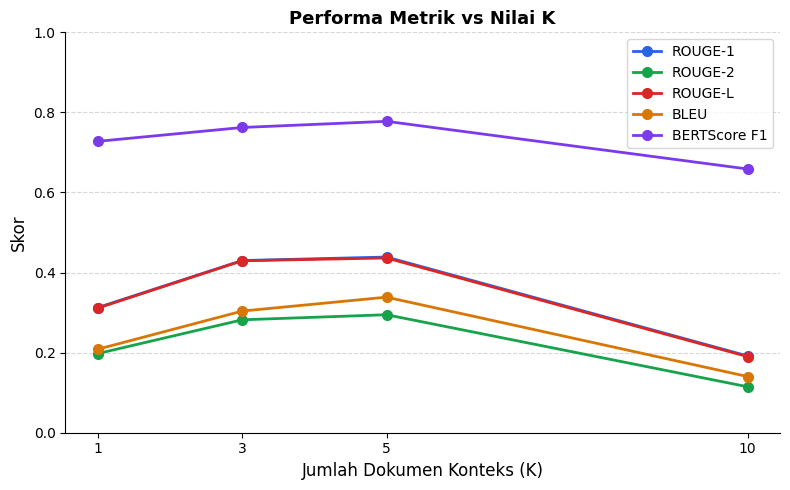

Grafik tersimpan sebagai grafik_metrik_vs_k.png


In [56]:
import matplotlib.pyplot as plt

metrics = {
    'ROUGE-1'      : 'rouge1',
    'ROUGE-2'      : 'rouge2',
    'ROUGE-L'      : 'rougeL',
    'BLEU'         : 'bleu',
    'BERTScore F1' : 'bertscore_F1',
}
colors = ['#2563EB', '#16a34a', '#dc2626', '#d97706', '#7c3aed']
k_vals = df_agg['k'].tolist()

fig, ax = plt.subplots(figsize=(8, 5))

for (label, col), color in zip(metrics.items(), colors):
    vals = df_agg[col].tolist()
    ax.plot(k_vals, vals, marker='o', label=label,
            linewidth=2, markersize=7, color=color)

ax.set_xticks([1, 3, 5, 10])
ax.set_xlabel('Jumlah Dokumen Konteks (K)', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Performa Metrik vs Nilai K', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik_metrik_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan sebagai grafik_metrik_vs_k.png")

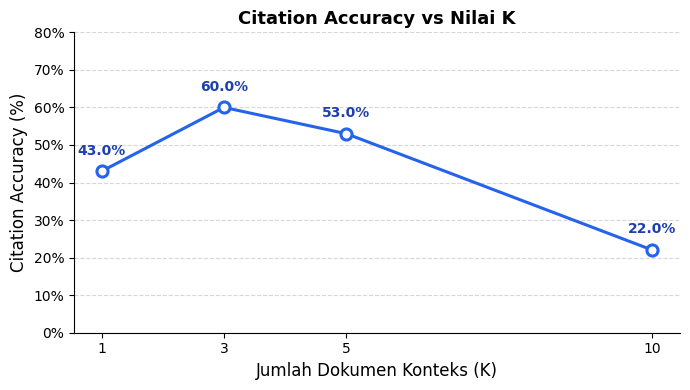

Grafik tersimpan sebagai grafik_citation_accuracy.png


In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    df_citation['k'],
    df_citation['citation_accuracy'] * 100,
    marker='o', linewidth=2.2, markersize=8,
    color='#2563EB', markerfacecolor='white', markeredgewidth=2.2
)

# Anotasi nilai di tiap titik
for _, row in df_citation.iterrows():
    ax.annotate(
        f"{row['citation_accuracy']*100:.1f}%",
        xy=(row['k'], row['citation_accuracy'] * 100),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=10, color='#1e40af', fontweight='bold'
    )

ax.set_xticks([1, 3, 5, 10])
ax.set_xlabel('Jumlah Dokumen Konteks (K)', fontsize=12)
ax.set_ylabel('Citation Accuracy (%)', fontsize=12)
ax.set_title('Citation Accuracy vs Nilai K', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_ylim(0, 80)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('grafik_citation_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan sebagai grafik_citation_accuracy.png")